# Deepweeds - MobileNetv3Small

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2025-07-05 02:43:42.219697: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-05 02:43:42.219833: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-05 02:43:42.341780: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 1
oversampling = 0 # How many times are we gonna over sample

## Subspace_Bottleneck_FCLayer Config
NUM_SPACES = 4 #Experiment 3
FINAL_FEAT_SIZE = 1024 #Mobilenet V3 Small - Feature Size

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
IMG_SIZE=(224,224,3)

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = False
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### After Base Model Freezing and Appending Subspace FC Layer. Training only FC Layer.
INIT_LR2 = 2e-6 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-4 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 2 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  676  637  619  613  637  605  644  610  5463 	Total: (10504, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1822 	Total: (3502, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  205  213  202  215  203  1821 	Total: (3503, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10504 files belonging to 9 classes.
Found 3502 files belonging to 9 classes.
Found 3503 files belonging to 9 classes.


# Sample Images

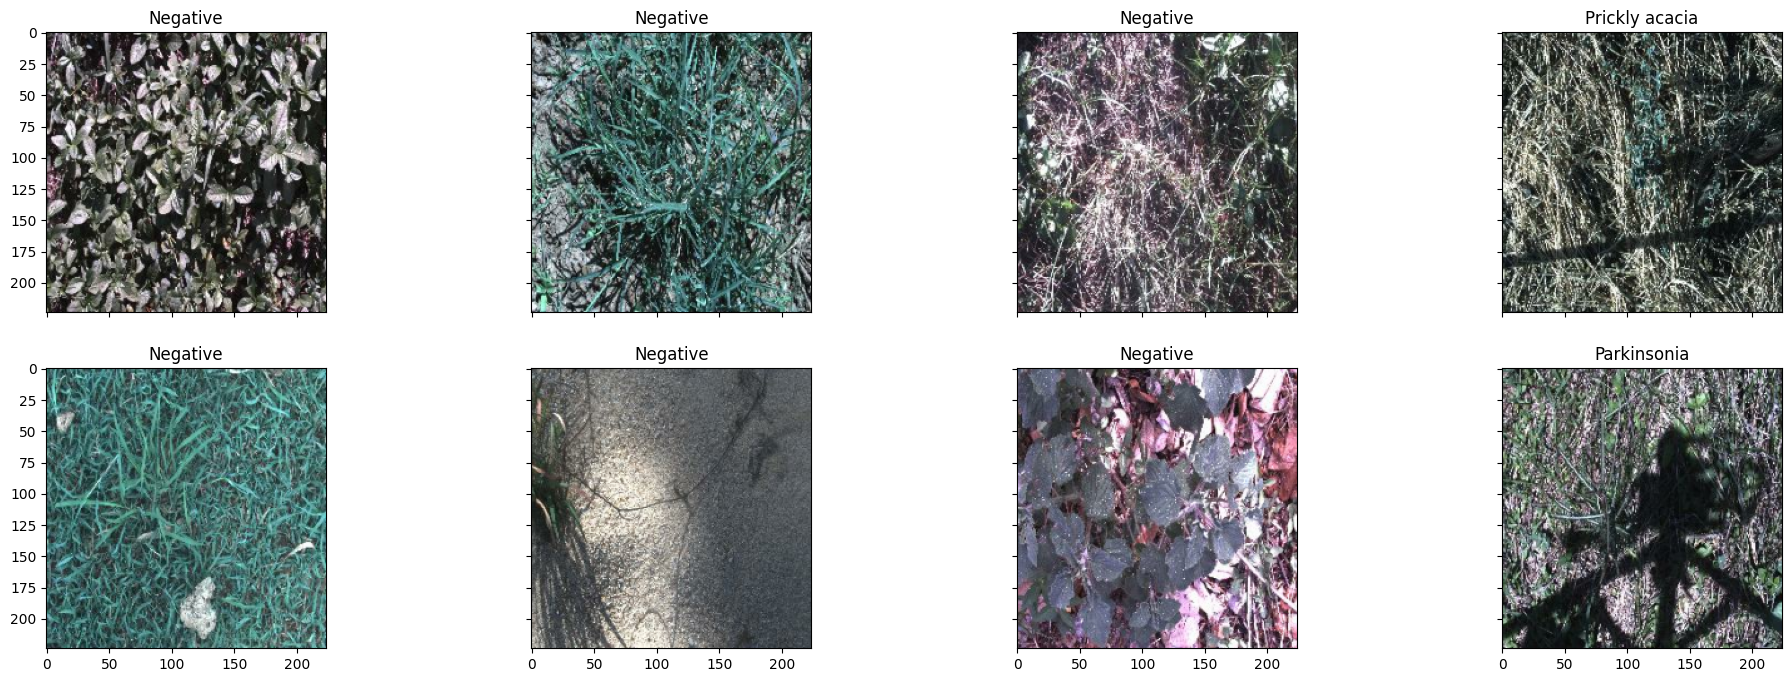

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax


def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# Building MobileNet Model

In [18]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model


def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def MobilenetV3Base(img_size):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start - #conv_layer
    pi1 = base_index+2 # pooler index end - # activation
    for i in range(base_index, len(mobilenet.layers)):
        if('dropout' in mobilenet.layers[i].name):
            pi1 = i
            break
    
    FCLayer = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-FCLayer")
    
    return base_model , FCLayer

def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2
    
    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape),
        layers.Reshape((n_spaces, -1), name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=keras.regularizers.L1L2(0.01,0.01), name="SubspaceFC_Bottleneck_Compress"),
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout")
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer
    

def buildModel(IMG_SIZE, fusion_type='average', cbam_order='normal', skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, FCLayer = MobilenetV3Base(IMG_SIZE)
    base_model.trainable = True
    FCLayer.trainable = True
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))

    ####----------------------------------------------
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')
    x = inputs

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=SEED)(x) 
    
    x = layers.GlobalAveragePooling2D(keepdims=True)(x)
    
    bottleneck = subSpaceBottleneckFCLayer(x.shape[1:], NUM_SPACES, FINAL_FEAT_SIZE)
    x = bottleneck(x)
    
    x = layers.Flatten()(x)
    outputs = layers.Dense(9, activation='softmax', name='classifier')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [19]:
with strategy.scope():
    model = buildModel(IMG_SIZE)
model.summary()

10734624/10734624 [==============================] - 2s 0us/step
Base Model: MobilenetV3small_base_
228
Model: "augment_pipeline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RR_Bright (RandomBrightnes  (None, 224, 224, 3)       0         
 s)                                                              
                                                                 
 RR_Flip (RandomFlip)        (None, 224, 224, 3)       0         
                                                                 
 RR_Rot (RandomRotation)     (None, 224, 224, 3)       0         
                                                                 
 RR_Trans (RandomTranslatio  (None, 224, 224, 3)       0         
 n)                                                              
                                                                 
 RR_Zoom (RandomZoom)        (None, 224, 224, 3)       0         
            

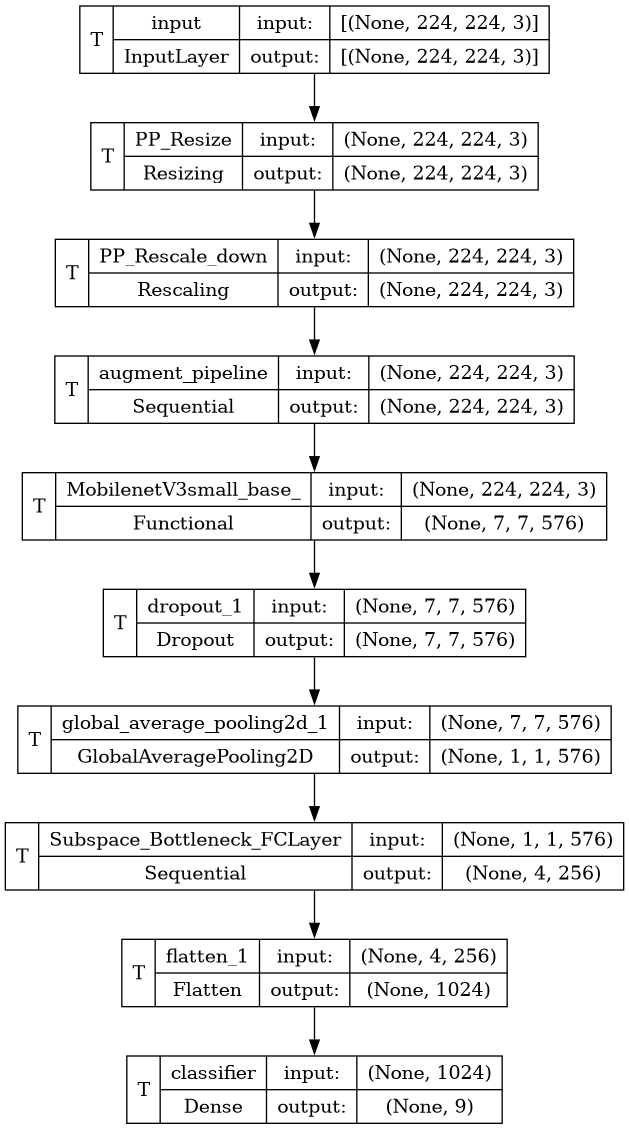

In [20]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [21]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(f"base_{MODEL_NAME}", save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    metrics = [] if isTPU else ['accuracy'] 
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

3
{'name': 'AdamW', 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 0.0002, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-05 02:47:05.018883: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1751683630.681181      68 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - 58s 84ms/step - loss: 28.1909 - accuracy: 0.5657 - val_loss: 5.3686 - val_accuracy: 0.6719 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 24s 73ms/step - loss: 1.0986 - accuracy: 0.5955 - val_loss: 0.2829 - val_accuracy: 0.6371 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 24s 73ms/step - loss: 0.2540 - accuracy: 0.6638 - val_loss: 0.2055 - val_accuracy: 0.7287 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1968 - accuracy: 0.7235 - val_loss: 0.1589 - val_accuracy: 0.8041 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 24s 73ms/step - loss: 0.1664 - accuracy: 0.7577 - val_loss: 0.1343 - val_accuracy: 0.8215 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 24s 72ms/step - loss: 0.1487 - accuracy: 0.7838 - val_loss: 0.1297 - val_accuracy: 0.8261 - lr: 2.0000e-04
Epoch 7/300
329/329 [==================

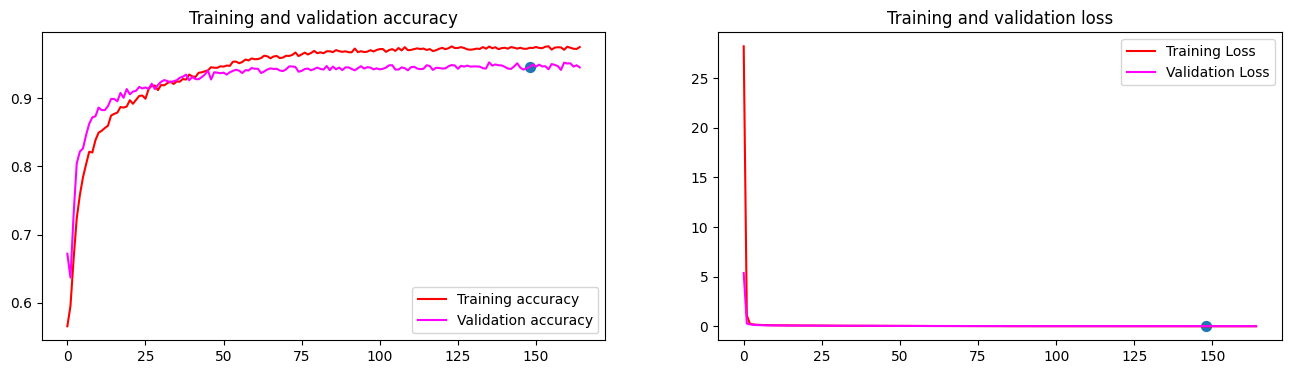

CPU times: user 2h 10min 32s, sys: 10min 23s, total: 2h 20min 55s
Wall time: 1h 5min 46s


In [22]:
%%time

# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=callbacks,
    )

# Plot training results
plot_loss_acc(history1.history)

# Evaluations #1A

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0234 - accuracy: 0.9455
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.86036   0.84889   0.85459       225
       Lantana    0.93396   0.92958   0.93176       213
   Parkinsonia    0.97101   0.97573   0.97337       206
    Parthenium    0.96059   0.95588   0.95823       204
Prickly acacia    0.91705   0.93868   0.92774       212
   Rubber vine    0.93103   0.93564   0.93333       202
     Siam weed    0.94762   0.92558   0.93647       215
    Snake weed    0.92147   0.86700   0.89340       203
      Negative    0.96189   0.96981   0.96584      1822

      accuracy                        0.94660      3502
     macro avg    0.93389   0.92742   0.93053      3502
  weighted avg    0.94642   0.94660   0.94643      3502


                False Positive Rate  Accuracy
Chinee apple               0.009460  0.848889
Lantana                    0.004257  0.929577
Parkinsonia                0.001820  0.975728
Parthenium                 0.002426  0.955882
Prickly acacia    

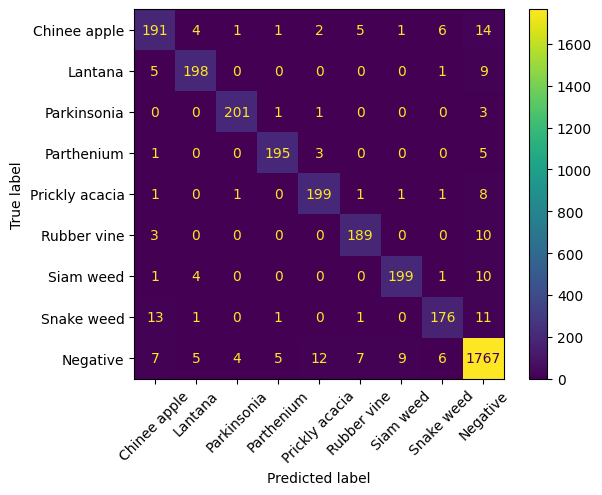

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 25ms/step - loss: 0.6556 - accuracy: 0.4713
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.12214   0.07111   0.08989       225
       Lantana    0.14433   0.06573   0.09032       213
   Parkinsonia    0.37500   0.05825   0.10084       206
    Parthenium    0.12329   0.04390   0.06475       205
Prickly acacia    0.19355   0.02817   0.04918       213
   Rubber vine    0.17143   0.05941   0.08824       202
     Siam weed    0.20690   0.05581   0.08791       215
    Snake weed    0.14815   0.05911   0.08451       203
      Negative    0.53174   0.85557   0.65586      1821

      accuracy                        0.47131      3503
     macro avg    0.22406   0.14412   0.14572      3503
  weighted avg    0.36525   0.47131   0.38030      3503


                False Positive Rate  Accuracy
Chinee apple               0.035082  0.071111
Lantana                    0.025228  0.065728
Parkinsonia                0.006066  0.058252
Parthenium                 0.019406  0.043902
Prickly acacia    

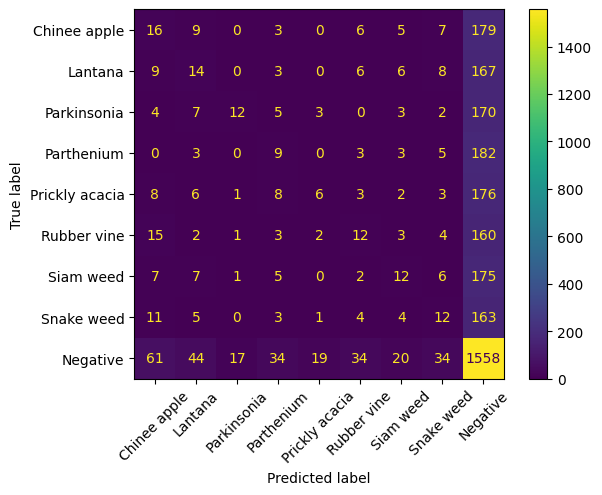

In [23]:
print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")   
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [24]:
with strategy.scope():
    for layer in model.layers:
        if 'base' in layer.name.lower():
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer MobilenetV3small_base_ True


# Evaluations #1B

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 22ms/step - loss: 0.0050 - accuracy: 0.9912
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99703   0.99408   0.99556       676
       Lantana    0.99376   1.00000   0.99687       637
   Parkinsonia    0.99518   1.00000   0.99758       619
    Parthenium    0.98080   1.00000   0.99031       613
Prickly acacia    0.99368   0.98744   0.99055       637
   Rubber vine    0.99670   0.99835   0.99752       605
     Siam weed    0.99844   0.99224   0.99533       644
    Snake weed    0.99342   0.99016   0.99179       610
      Negative    0.99725   0.99579   0.99652      5463

      accuracy                        0.99553     10504
     macro avg    0.99403   0.99534   0.99467     10504
  weighted avg    0.99554   0.99553   0.99553     10504


                False Positive Rate  Accuracy
Chinee apple               0.000204  0.994083
Lantana                    0.000405  1.000000
Parkinsonia                0.000303  1.000000
Parthenium                 0.001213  1.000000
Prickly acacia    

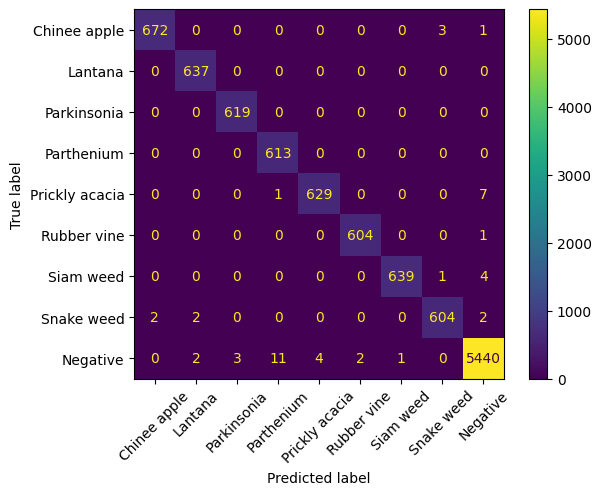

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0226 - accuracy: 0.9457
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.89302   0.85333   0.87273       225
       Lantana    0.95261   0.94366   0.94811       213
   Parkinsonia    0.97549   0.96602   0.97073       206
    Parthenium    0.92166   0.98039   0.95012       204
Prickly acacia    0.93023   0.94340   0.93677       212
   Rubber vine    0.97015   0.96535   0.96774       202
     Siam weed    0.95755   0.94419   0.95082       215
    Snake weed    0.88725   0.89163   0.88943       203
      Negative    0.97367   0.97420   0.97394      1822

      accuracy                        0.95545      3502
     macro avg    0.94018   0.94024   0.94004      3502
  weighted avg    0.95545   0.95545   0.95536      3502


                False Positive Rate  Accuracy
Chinee apple               0.007019  0.853333
Lantana                    0.003040  0.943662
Parkinsonia                0.001517  0.966019
Parthenium                 0.005155  0.980392
Prickly acacia    

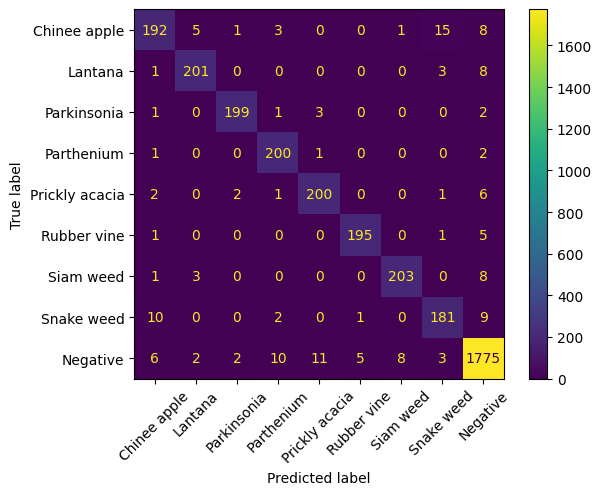

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 24ms/step - loss: 0.6556 - accuracy: 0.4713
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.88837   0.84889   0.86818       225
       Lantana    0.92593   0.93897   0.93240       213
   Parkinsonia    0.94419   0.98544   0.96437       206
    Parthenium    0.92627   0.98049   0.95261       205
Prickly acacia    0.95714   0.94366   0.95035       213
   Rubber vine    0.98969   0.95050   0.96970       202
     Siam weed    0.98529   0.93488   0.95943       215
    Snake weed    0.87745   0.88177   0.87961       203
      Negative    0.97101   0.97474   0.97287      1821

      accuracy                        0.95432      3503
     macro avg    0.94059   0.93770   0.93883      3503
  weighted avg    0.95445   0.95432   0.95422      3503


                False Positive Rate  Accuracy
Chinee apple               0.007322  0.848889
Lantana                    0.004863  0.938967
Parkinsonia                0.003640  0.985437
Parthenium                 0.004851  0.980488
Prickly acacia    

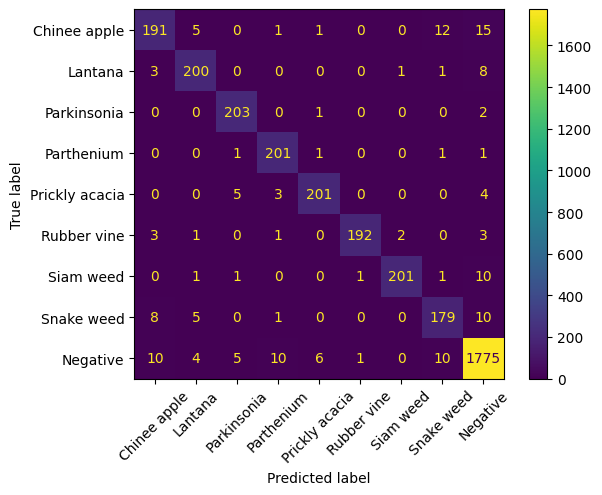

In [25]:
## Test After Freezing
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")   
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.82158   0.88000   0.84979       225
       Lantana    0.83951   0.95775   0.89474       213
   Parkinsonia    0.94419   0.98544   0.96437       206
    Parthenium    0.92627   0.98049   0.95261       205
Prickly acacia    0.86134   0.96244   0.90909       213
   Rubber vine    0.98969   0.95050   0.96970       202
     Siam weed    0.98529   0.93488   0.95943       215
    Snake weed    0.87745   0.88177   0.87961       203
      Negative    0.97939   0.93959   0.95908      1821

      accuracy                        0.94034      3503
     macro avg    0.91386   0.94143   0.92649      3503
  weighted avg    0.94344   0.94034   0.94107      3503


                False Positive Rate  Accuracy
Chinee apple               0.013118  0.880000
Lantana                    0.011854  0.957746
Parkinsonia                0.003640  0.985437
Parthenium                 0.004851  0.980488
Prickly acacia    

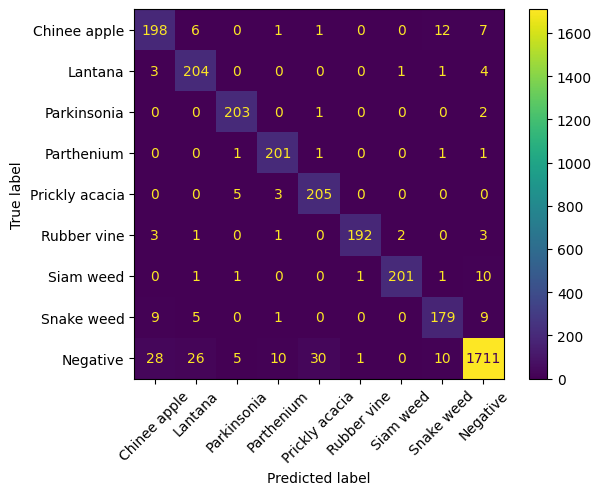

In [26]:
printStats(a,b,0.11)

# Trial 2

In [27]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
    metrics = [] if isTPU else ['accuracy']
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=metrics)

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'AdamW', 'weight_decay': 0.0005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 2e-06, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2025-07-05 03:57:12.573631: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 17s 39ms/step - loss: 0.0175 - accuracy: 0.9513 - val_loss: 0.0211 - val_accuracy: 0.9543 - lr: 2.0000e-06
Epoch 2/300
329/329 [==============================] - 12s 35ms/step - loss: 0.0169 - accuracy: 0.9534 - val_loss: 0.0213 - val_accuracy: 0.9552 - lr: 2.0000e-06
Epoch 3/300
329/329 [==============================] - 12s 37ms/step - loss: 0.0169 - accuracy: 0.9513 - val_loss: 0.0215 - val_accuracy: 0.9549 - lr: 2.0000e-06
Epoch 4/300
328/329 [============================>.] - ETA: 0s - loss: 0.0159 - accuracy: 0.9571
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999959603884e-06.
329/329 [==============================] - 12s 35ms/step - loss: 0.0159 - accuracy: 0.9571 - val_loss: 0.0215 - val_accuracy: 0.9546 - lr: 2.0000e-06
Epoch 5/300
329/329 [==============================] - 12s 35ms/step - loss: 0.0151 - accuracy: 0.9571 - val_loss: 0.0215 - val_accuracy: 0.9549 - lr: 1.6000e-06
Epoch 6/300
329/329 [===================

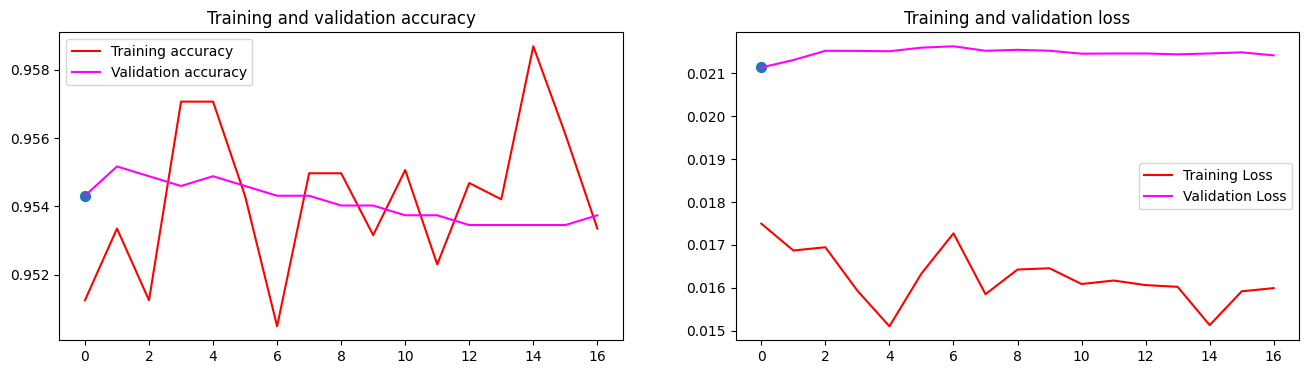

CPU times: user 9min 14s, sys: 57.3 s, total: 10min 11s
Wall time: 3min 40s


In [28]:
%%time

# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr]
    )

print("Saving the Checkpoint")
model.save(MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)


# Accuracy / Loss Plots

Total Epochs: range(0, 182)


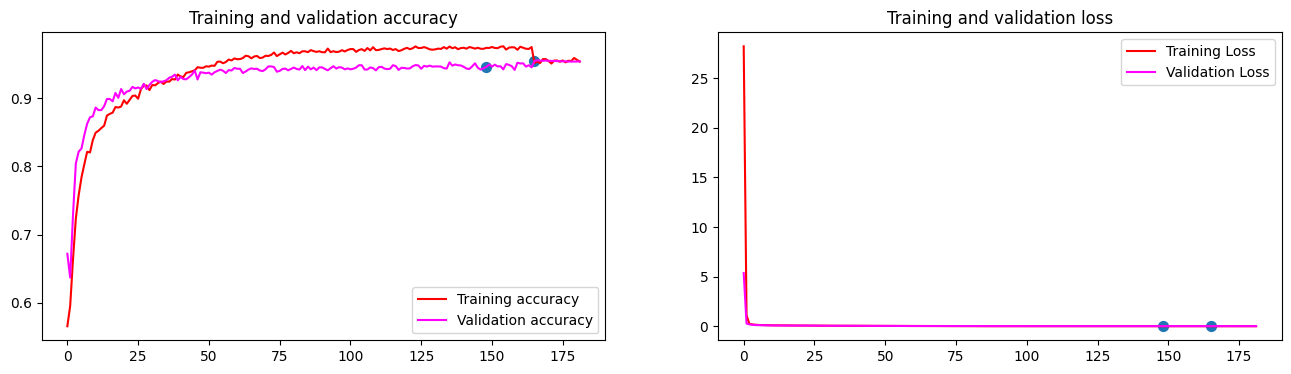

In [29]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 165)


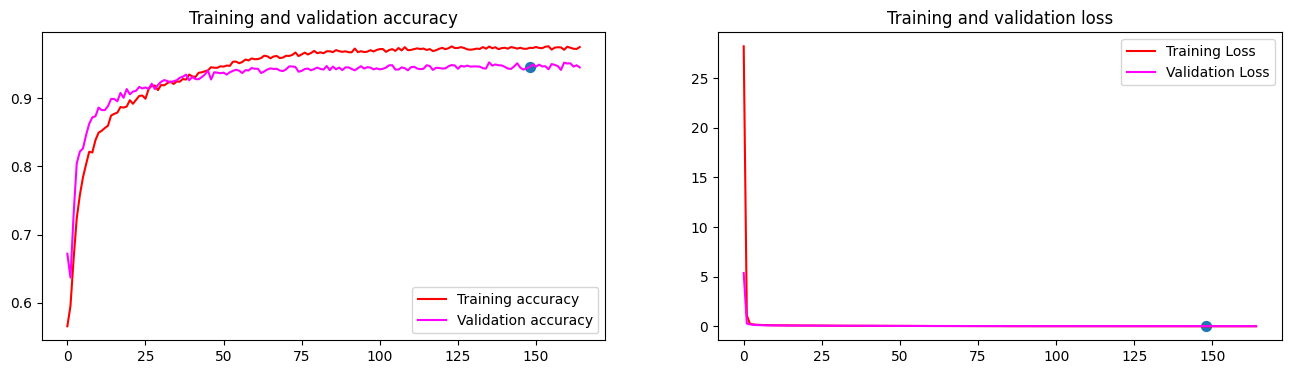

Total Epochs: range(0, 17)


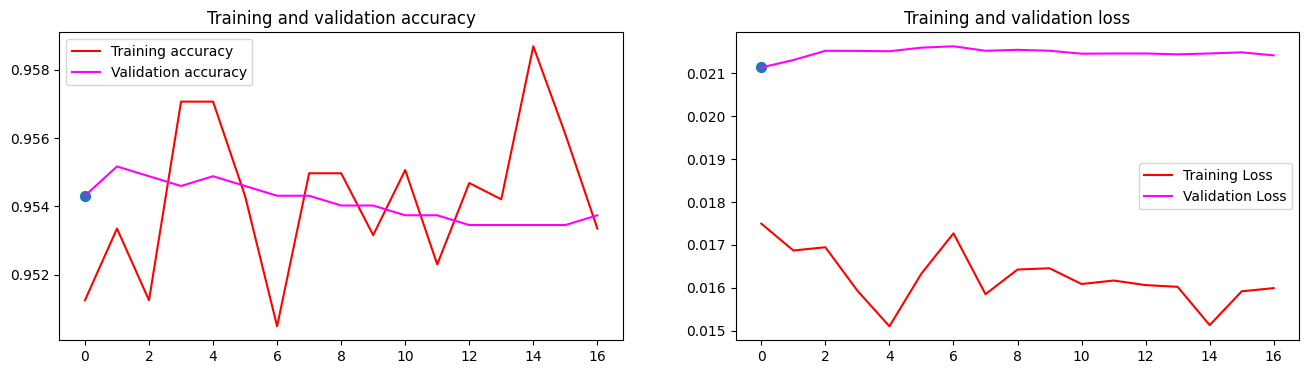

In [30]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 7s 22ms/step - loss: 0.0040 - accuracy: 0.9952
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99553   0.98817   0.99183       676
       Lantana    0.99376   1.00000   0.99687       637
   Parkinsonia    0.99518   1.00000   0.99758       619
    Parthenium    0.98712   1.00000   0.99352       613
Prickly acacia    0.99058   0.99058   0.99058       637
   Rubber vine    0.99507   1.00000   0.99753       605
     Siam weed    0.99844   0.99224   0.99533       644
    Snake weed    0.98371   0.99016   0.98693       610
      Negative    0.99780   0.99542   0.99661      5463

      accuracy                        0.99524     10504
     macro avg    0.99302   0.99517   0.99409     10504
  weighted avg    0.99526   0.99524   0.99524     10504


                False Positive Rate  Accuracy
Chinee apple               0.000305  0.988166
Lantana                    0.000405  1.000000
Parkinsonia                0.000303  1.000000
Parthenium                 0.000809  1.000000
Prickly acacia    

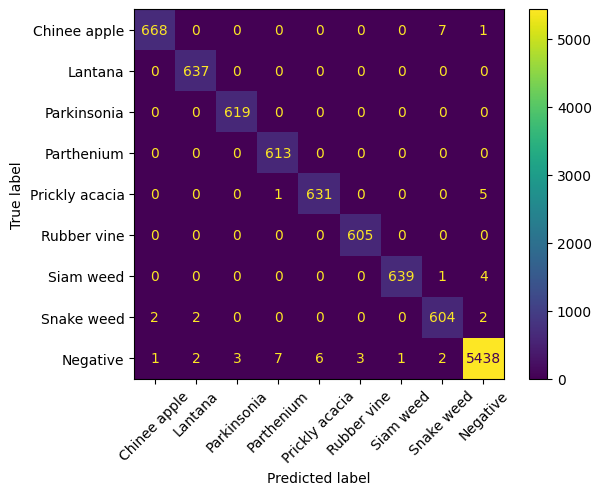


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 21ms/step - loss: 0.0211 - accuracy: 0.9543
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.90821   0.83556   0.87037       225
       Lantana    0.94860   0.95305   0.95082       213
   Parkinsonia    0.97549   0.96602   0.97073       206
    Parthenium    0.91705   0.97549   0.94537       204
Prickly acacia    0.92237   0.95283   0.93735       212
   Rubber vine    0.96535   0.96535   0.96535       202
     Siam weed    0.94495   0.95814   0.95150       215
    Snake weed    0.87560   0.90148   0.88835       203
      Negative    0.97517   0.96981   0.97248      1822

      accuracy                        0.95431      3502
     macro avg    0.93698   0.94197   0.93915      3502
  weighted avg    0.95449   0.95431   0.95422      3502


                False Positive Rate  Accuracy
Chinee apple               0.005798  0.835556
Lantana                    0.003344  0.953052
Parkinsonia                0.001517  0.966019
Parthenium                 0.005458  0.975490
Prickly acacia    

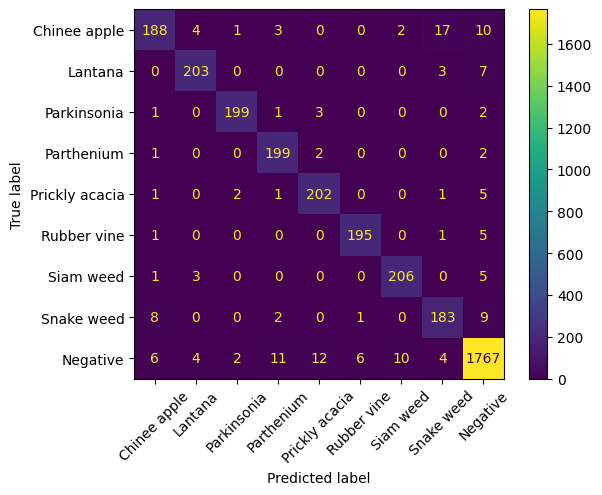


Testn Set Statistics
model.evaluate
110/110 [==============================] - 2s 21ms/step - loss: 0.0207 - accuracy: 0.9560
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.91220   0.83111   0.86977       225
       Lantana    0.92308   0.95775   0.94009       213
   Parkinsonia    0.94860   0.98544   0.96667       206
    Parthenium    0.92627   0.98049   0.95261       205
Prickly acacia    0.95283   0.94836   0.95059       213
   Rubber vine    0.98969   0.95050   0.96970       202
     Siam weed    0.97630   0.95814   0.96714       215
    Snake weed    0.84722   0.90148   0.87351       203
      Negative    0.97683   0.97254   0.97468      1821

      accuracy                        0.95604      3503
     macro avg    0.93922   0.94287   0.94053      3503
  weighted avg    0.95653   0.95604   0.95600      3503


                False Positive Rate  Accuracy
Chinee apple               0.005491  0.831111
Lantana                    0.005167  0.957746
Parkinsonia                0.003336  0.985437
Parthenium                 0.004851  0.980488
Prickly acacia    

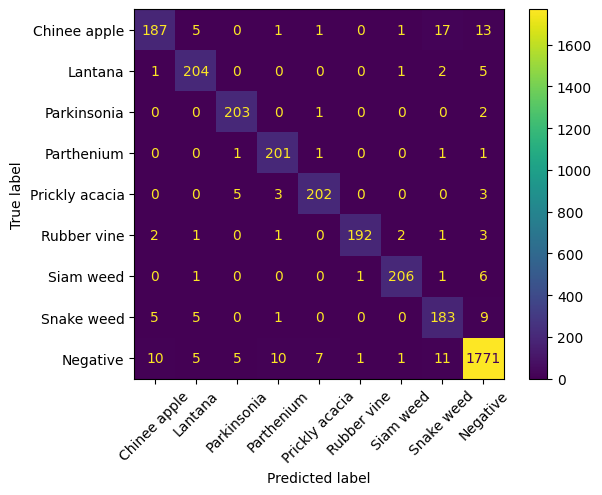

In [31]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.85333   0.85333   0.85333       225
       Lantana    0.81746   0.96714   0.88602       213
   Parkinsonia    0.94860   0.98544   0.96667       206
    Parthenium    0.92627   0.98049   0.95261       205
Prickly acacia    0.86134   0.96244   0.90909       213
   Rubber vine    0.98969   0.95050   0.96970       202
     Siam weed    0.97630   0.95814   0.96714       215
    Snake weed    0.84722   0.90148   0.87351       203
      Negative    0.98272   0.93685   0.95924      1821

      accuracy                        0.94034      3503
     macro avg    0.91144   0.94398   0.92637      3503
  weighted avg    0.94383   0.94034   0.94110      3503


                False Positive Rate  Accuracy
Chinee apple               0.010067  0.853333
Lantana                    0.013982  0.967136
Parkinsonia                0.003336  0.985437
Parthenium                 0.004851  0.980488
Prickly acacia    

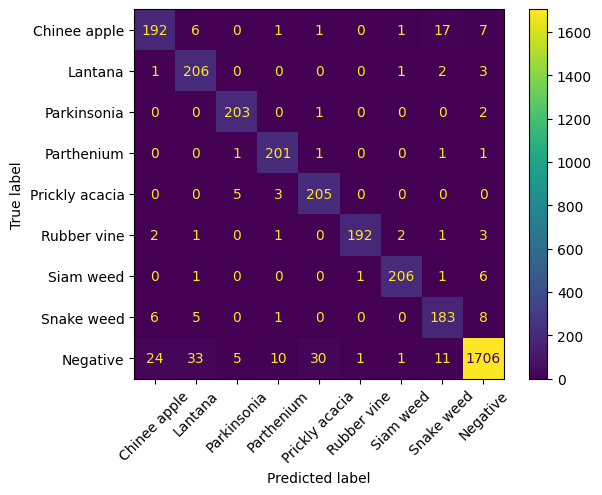

In [32]:
printStats(a,b,0.11)

## Clear Files

In [33]:
shutil.rmtree(base_dir)